In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:

merged = pd.read_csv("../data/merged.csv")
print(merged.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures_mat', 'schoolsup', 'famsup', 'paid_mat', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences_mat', 'G1_mat', 'G2_mat',
       'G3_mat', 'failures_por', 'paid_por', 'absences_por', 'G1_por',
       'G2_por', 'G3_por', 'reussite_mat', 'reussite_por', 'reussite'],
      dtype='object')


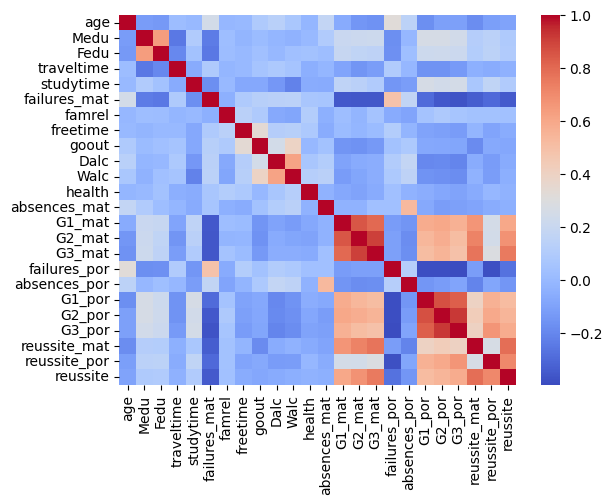

In [3]:
# heatmap sur les var quantitatives
sns.heatmap(merged.corr(numeric_only=True),cmap="coolwarm")
plt.show()

# On remarque qu'il n'y a pas de corrélation transcendante entre les variables numériques
# Seules les notes Gi le sont ce qui parait logique
# On remarque aussi que Medu et Fedu ainsi que Walc et Dalc le sont ce qui est plutôt logique 
# (quelqu'un qui boit de l'alcool le week-end a plus de chance d'en boire la semaine et inversement/ 
# il est aussi probable que les catégories sociaux professionnelles des parents soient similaire)

# On se demande donc si l'analyse PCA sera pertinente si les variables sont peu corrélés (Difficile pour un axe de capter beuacoup d'inertie)

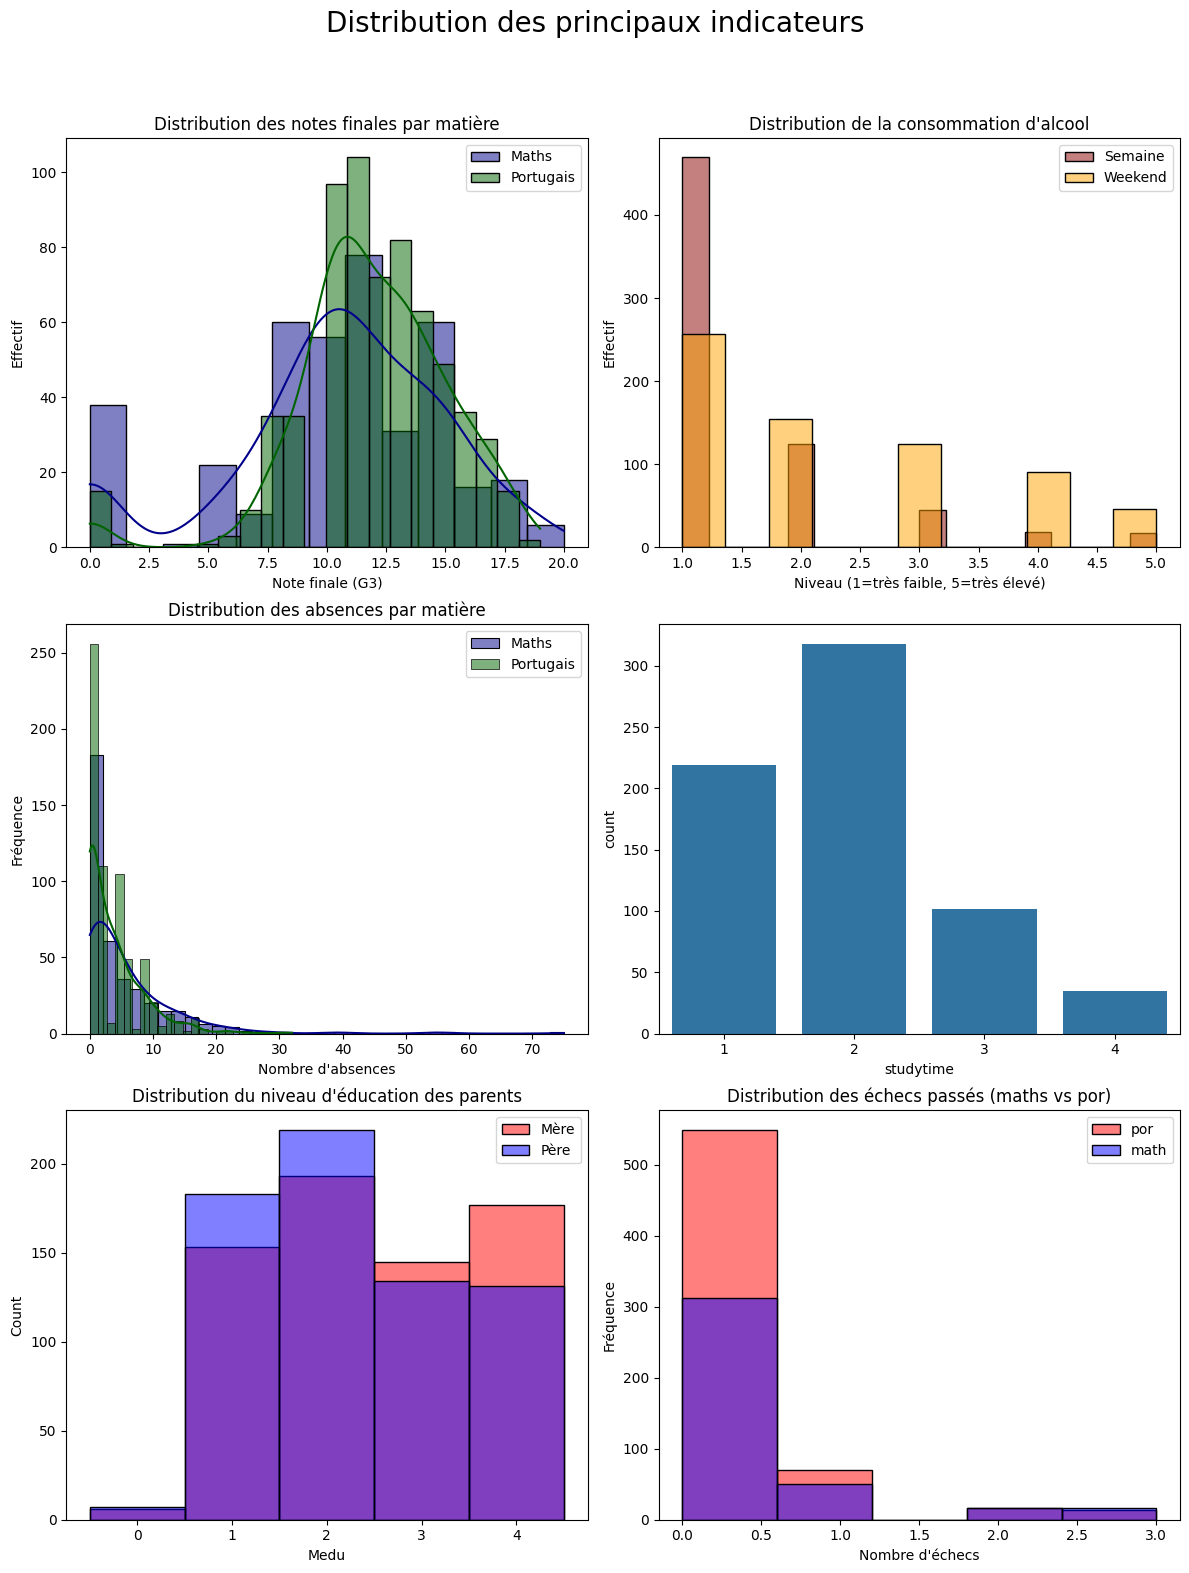

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
fig.suptitle('Distribution des principaux indicateurs', fontsize=20)

# Notes finales math vs portugais
sns.histplot(merged['G3_mat'].dropna(), ax=axes[0, 0], color='darkblue', label='Maths', kde=True, stat='count', alpha=0.5)
sns.histplot(merged['G3_por'].dropna(), ax=axes[0, 0], color='darkgreen', label='Portugais', kde=True, stat='count', alpha=0.5)
axes[0, 0].set_title('Distribution des notes finales par matière')
axes[0, 0].set_xlabel('Note finale (G3)')
axes[0, 0].set_ylabel('Effectif')
axes[0, 0].legend()

# Les notes de mat et por semblent toutes les 2 suivre un genre de loi normal mais les notes de portugais sont meilleus en moyenne qu'en math

# Consommation d'alcool
sns.histplot(merged['Dalc'], ax=axes[0, 1], color='darkred', label='Semaine', stat='count', alpha=0.5)
sns.histplot(merged['Walc'], ax=axes[0, 1], color='orange', label='Weekend', stat='count', alpha=0.5)
axes[0, 1].set_title("Distribution de la consommation d'alcool")
axes[0, 1].set_xlabel('Niveau (1=très faible, 5=très élevé)')
axes[0, 1].set_ylabel('Effectif')
axes[0, 1].legend()

# Rappel
# Dalc - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
# Walc - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)
# La plupart des etudiants consomment moins d'alcool en semaine que le week-end ce qui est vraisemblable




# Absences math vs portugais
sns.histplot(merged['absences_mat'].dropna(), kde=True, ax=axes[1, 0], color='darkblue', label='Maths')
sns.histplot(merged['absences_por'].dropna(), kde=True, ax=axes[1, 0], color='darkgreen', label='Portugais')
axes[1, 0].set_title('Distribution des absences par matière')
axes[1, 0].set_xlabel('Nombre d\'absences')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

# On remarque qu'il y a beaucoup plus d'abscences ponctuelles en cours de portugais qu'en math
# Cependant si on s'interesse à nb_absence > 10 il semble y en avoir plus math
# On peut supposer que le portugais est un cours pas forcement pris au sérieux ( les élèvent séchent tous quelques cours)
# Et que pour les maths il y a par contre plus d'élèves qui abandonnent la matière et qui donc ont un taux d'abscence élevé

# Temps d'étude hebdomadaire
sns.countplot(x=merged['studytime'], ax=axes[1, 1])
axes[2, 1].set_title('Temps d\'étude hebdomadaire')

# Rappel studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
# La majorité des étudiants étudient moins de 5h par semaine


# Éducation des parents
sns.histplot(merged['Medu'], bins=5, discrete=True, ax=axes[2, 0],
             color='red', alpha=0.5, label='Mère')

sns.histplot(merged['Fedu'], bins=5, discrete=True, ax=axes[2, 0],
             color='blue', alpha=0.5, label='Père')

axes[2, 0].legend()
axes[2, 0].set_title('Distribution du niveau d\'éducation des parents')

# Rappel Medu - mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
#  Fedu - father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
# Les mères semblent plus éduquée académiquements que les pères


# Échecs passés
sns.histplot(merged['failures_por'], bins=5, discrete=False, ax=axes[2, 1],
             color='red', alpha=0.5, label='por')

sns.histplot(merged['failures_mat'], bins=5, discrete=False, ax=axes[2, 1],
             color='blue', alpha=0.5, label='math')
axes[2, 1].set_title('Distribution des échecs passés (maths vs por)')
axes[2, 1].set_xlabel('Nombre d\'échecs')
axes[2, 1].set_ylabel('Fréquence')
axes[2, 1].legend()

# Le nombre de 'échecs semble similaire mais il y a un effet taille car il y a plus d'élèves en portugais qu'en math
# En voit donc qu'il y a plus d'echecs en math si on recoupe par les effectifs dans chaque matière
# Les échecs semblent rares, la plupart n'en ont aucun


plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [6]:
print(merged['failures_mat'])
print(merged['failures_mat'].dtype)
print(merged['failures_mat'].value_counts(dropna=False))

0      1.0
1      NaN
2      2.0
3      0.0
4      0.0
      ... 
669    NaN
670    0.0
671    NaN
672    2.0
673    3.0
Name: failures_mat, Length: 674, dtype: float64
float64
failures_mat
0.0    312
NaN    279
1.0     50
2.0     17
3.0     16
Name: count, dtype: int64


C:\Users\ellen\AppData\Local\Temp\ipykernel_32156\3951212774.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=g3_study, x='studytime', y='G3_mat', ax=axes[1,1], palette='Blues_d')
C:\Users\ellen\AppData\Local\Temp\ipykernel_32156\3951212774.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=g3_medu, x='Medu', y='G3_mat', ax=axes[2,0], palette='Reds_d')
C:\Users\ellen\AppData\Local\Temp\ipykernel_32156\3951212774.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=g3_famrel, x='famrel', y='G3_mat', ax=axes[3,2], palette

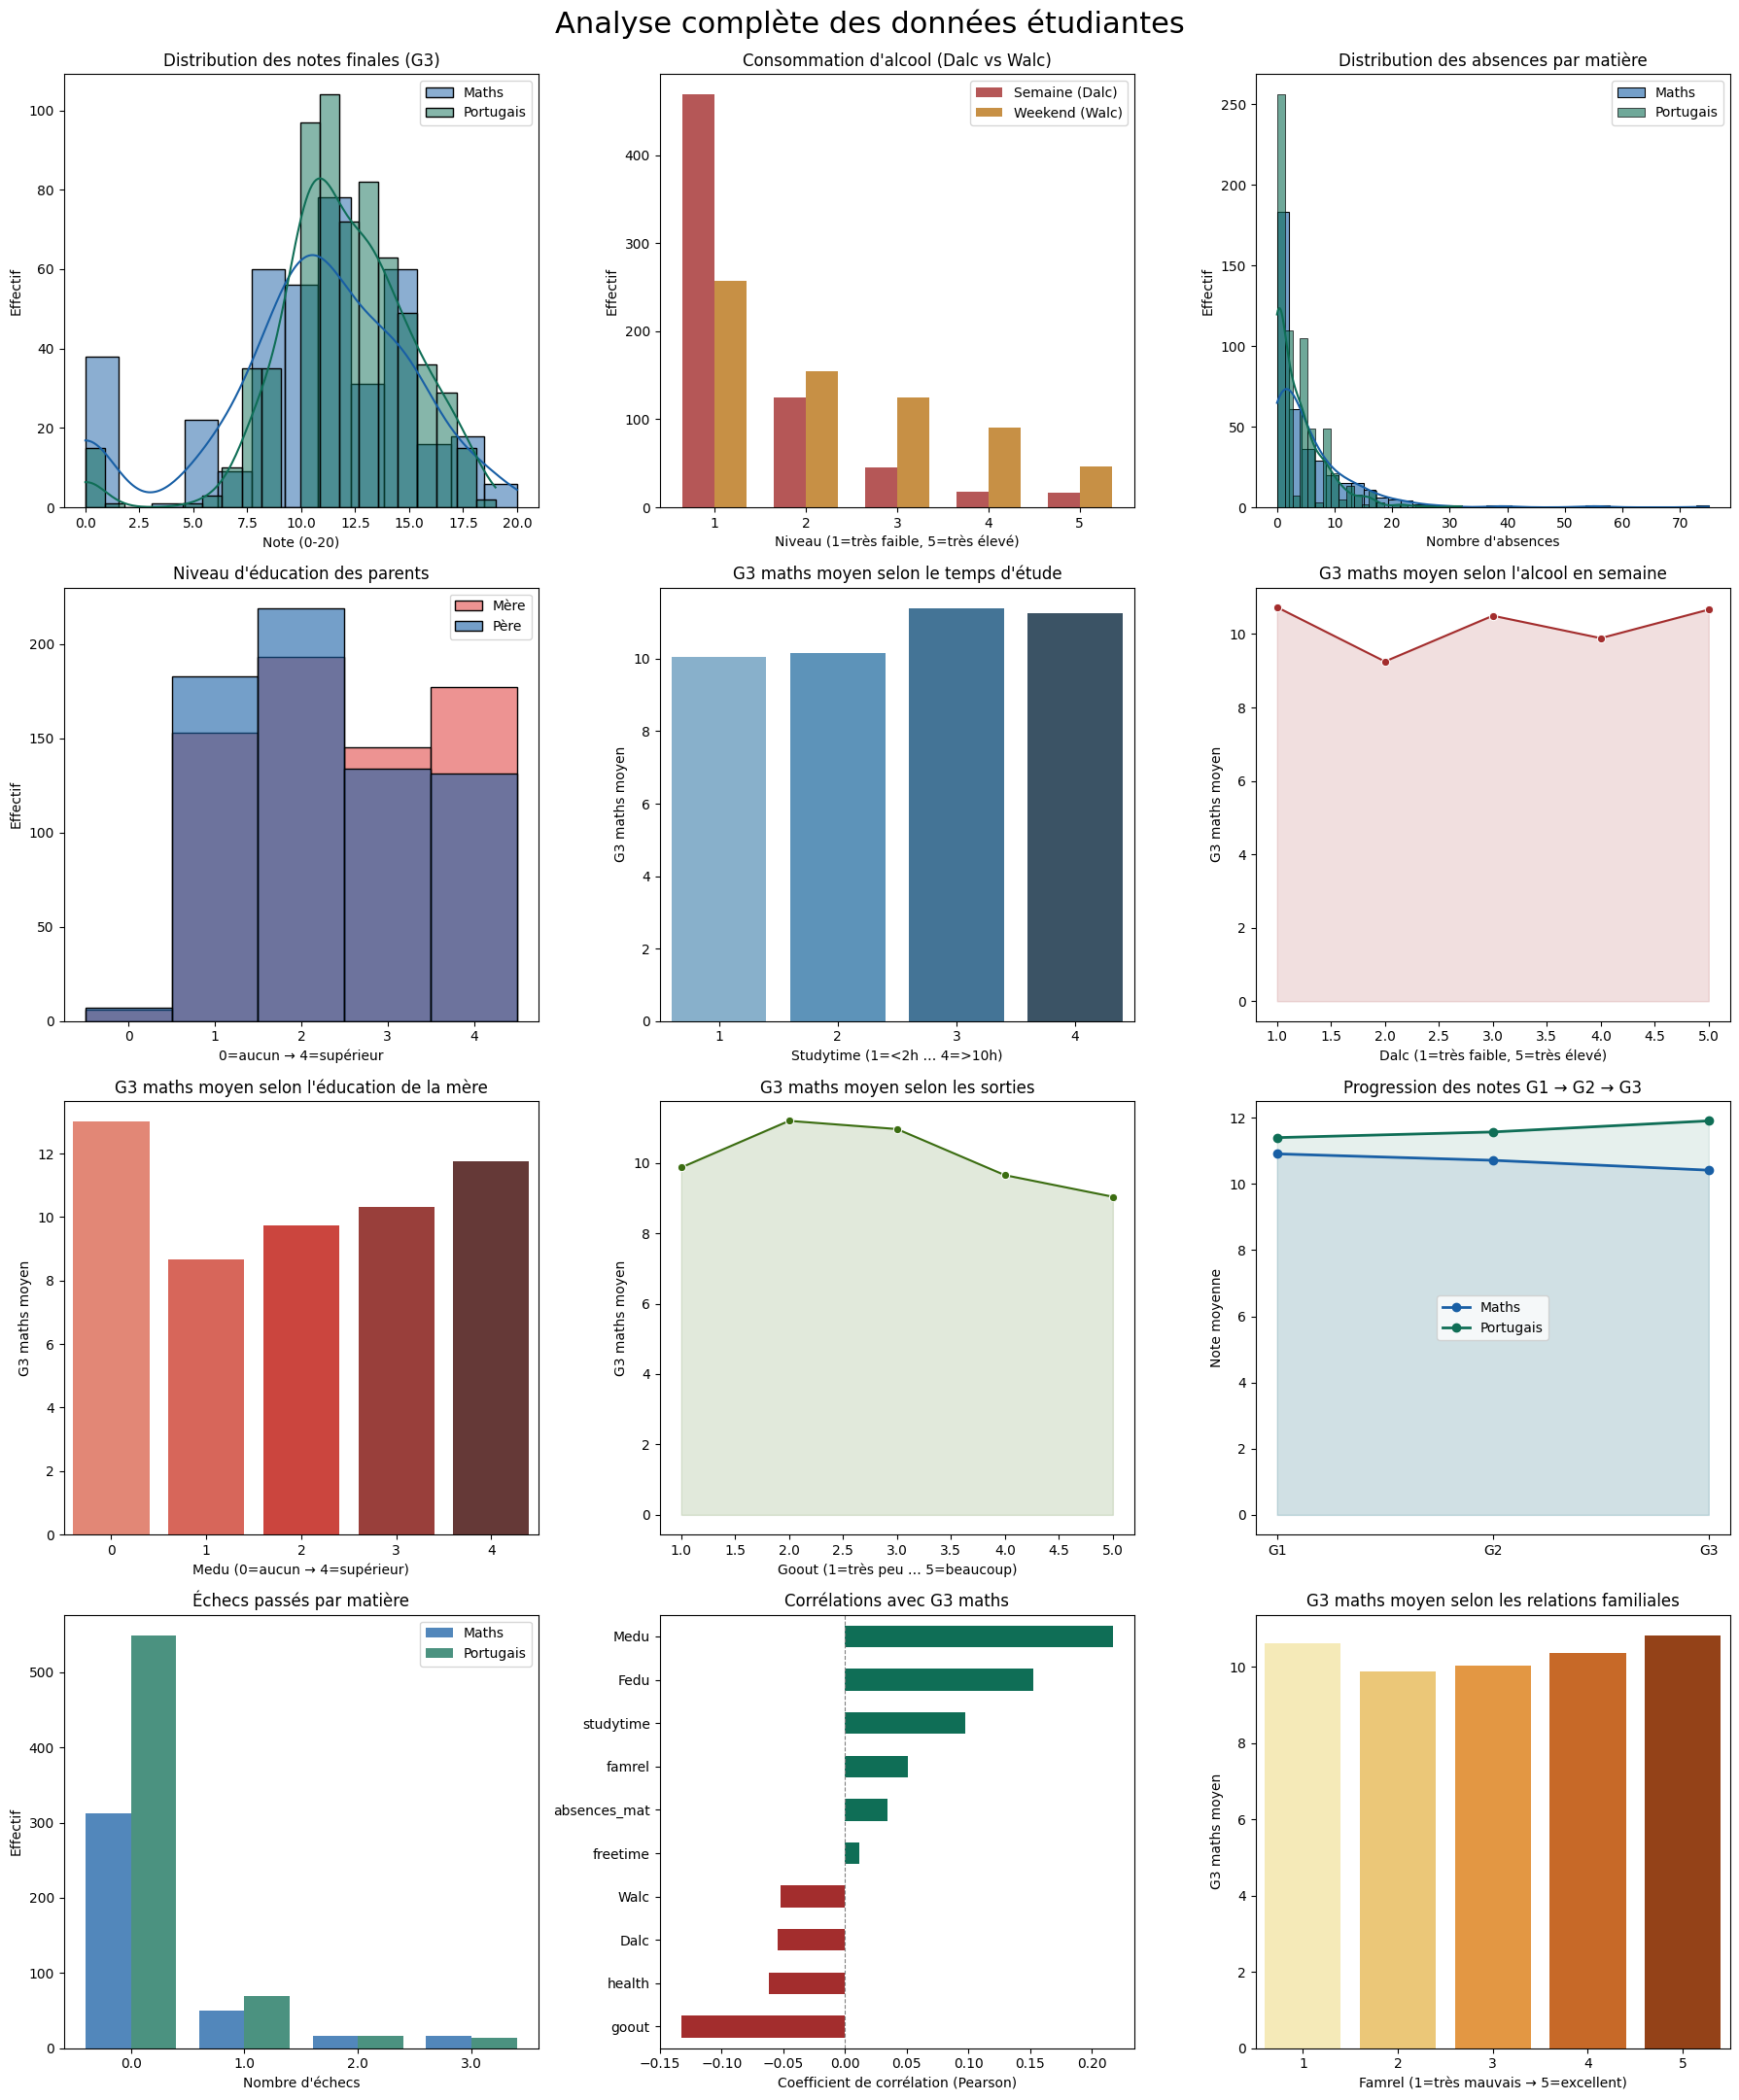

In [7]:

fig, axes = plt.subplots(4, 3, figsize=(18, 22))
fig.suptitle('Analyse complète des données étudiantes', fontsize=22, y=0.98)

# Notes finales
sns.histplot(merged['G3_mat'].dropna(), ax=axes[0,0], color='#185FA5', label='Maths', kde=True, alpha=0.5)
sns.histplot(merged['G3_por'].dropna(), ax=axes[0,0], color='#0F6E56', label='Portugais', kde=True, alpha=0.5)
axes[0,0].set_title('Distribution des notes finales (G3)')
axes[0,0].set_xlabel('Note (0-20)')
axes[0,0].set_ylabel('Effectif')
axes[0,0].legend()

# Alcool semaine vs weekend
alc_counts = merged[['Dalc','Walc']].apply(pd.Series.value_counts).fillna(0)
alc_counts.plot(kind='bar', ax=axes[0,1], color=['#A32D2D','#BA7517'], alpha=0.8, width=0.7)
axes[0,1].set_title("Consommation d'alcool (Dalc vs Walc)")
axes[0,1].set_xlabel('Niveau (1=très faible, 5=très élevé)')
axes[0,1].set_ylabel('Effectif')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(['Semaine (Dalc)', 'Weekend (Walc)'])

# Absences
sns.histplot(merged['absences_mat'].dropna(), ax=axes[0,2], color='#185FA5', label='Maths', kde=True, alpha=0.6)
sns.histplot(merged['absences_por'].dropna(), ax=axes[0,2], color='#0F6E56', label='Portugais', kde=True, alpha=0.6)
axes[0,2].set_title('Distribution des absences par matière')
axes[0,2].set_xlabel("Nombre d'absences")
axes[0,2].set_ylabel('Effectif')
axes[0,2].legend()

# Education des parents
sns.histplot(merged['Medu'], bins=5, discrete=True, ax=axes[1,0], color='#E24B4A', alpha=0.6, label='Mère')
sns.histplot(merged['Fedu'], bins=5, discrete=True, ax=axes[1,0], color='#185FA5', alpha=0.6, label='Père')
axes[1,0].set_title("Niveau d'éducation des parents")
axes[1,0].set_xlabel('0=aucun → 4=supérieur')
axes[1,0].set_ylabel('Effectif')
axes[1,0].legend()

# G3 maths selon studytime
g3_study = merged.groupby('studytime')['G3_mat'].mean().reset_index()
sns.barplot(data=g3_study, x='studytime', y='G3_mat', ax=axes[1,1], palette='Blues_d')
axes[1,1].set_title('G3 maths moyen selon le temps d\'étude')
axes[1,1].set_xlabel('Studytime (1=<2h … 4=>10h)')
axes[1,1].set_ylabel('G3 maths moyen')

# G3 maths selon Dalc
g3_dalc = merged.groupby('Dalc')['G3_mat'].mean().reset_index()
sns.lineplot(data=g3_dalc, x='Dalc', y='G3_mat', ax=axes[1,2], marker='o', color='#A32D2D')
axes[1,2].set_title("G3 maths moyen selon l'alcool en semaine")
axes[1,2].set_xlabel('Dalc (1=très faible, 5=très élevé)')
axes[1,2].set_ylabel('G3 maths moyen')
axes[1,2].fill_between(g3_dalc['Dalc'], g3_dalc['G3_mat'], alpha=0.15, color='#A32D2D')

# G3 maths selon Medu
g3_medu = merged.groupby('Medu')['G3_mat'].mean().reset_index()
sns.barplot(data=g3_medu, x='Medu', y='G3_mat', ax=axes[2,0], palette='Reds_d')
axes[2,0].set_title("G3 maths moyen selon l'éducation de la mère")
axes[2,0].set_xlabel('Medu (0=aucun → 4=supérieur)')
axes[2,0].set_ylabel('G3 maths moyen')

# G3 maths selon goout
g3_goout = merged.groupby('goout')['G3_mat'].mean().reset_index()
sns.lineplot(data=g3_goout, x='goout', y='G3_mat', ax=axes[2,1], marker='o', color='#3B6D11')
axes[2,1].set_title('G3 maths moyen selon les sorties')
axes[2,1].set_xlabel('Goout (1=très peu … 5=beaucoup)')
axes[2,1].set_ylabel('G3 maths moyen')
axes[2,1].fill_between(g3_goout['goout'], g3_goout['G3_mat'], alpha=0.15, color='#3B6D11')

# Progression G1 → G2 → G3
periods = ['G1', 'G2', 'G3']
mat_means = [merged['G1_mat'].mean(), merged['G2_mat'].mean(), merged['G3_mat'].mean()]
por_means = [merged['G1_por'].mean(), merged['G2_por'].mean(), merged['G3_por'].mean()]
axes[2,2].plot(periods, mat_means, marker='o', color='#185FA5', label='Maths', linewidth=2)
axes[2,2].plot(periods, por_means, marker='o', color='#0F6E56', label='Portugais', linewidth=2)
axes[2,2].set_title('Progression des notes G1 → G2 → G3')
axes[2,2].set_ylabel('Note moyenne')
axes[2,2].legend()
axes[2,2].fill_between(periods, mat_means, alpha=0.1, color='#185FA5')
axes[2,2].fill_between(periods, por_means, alpha=0.1, color='#0F6E56')

# Échecs passés
fail_mat = merged['failures_mat'].value_counts().sort_index()
fail_por = merged['failures_por'].value_counts().sort_index()
x = np.arange(len(fail_mat))
axes[3,0].bar(x - 0.2, fail_mat.values, width=0.4, color='#185FA5', alpha=0.75, label='Maths')
axes[3,0].bar(x + 0.2, fail_por.reindex(fail_mat.index, fill_value=0).values, width=0.4, color='#0F6E56', alpha=0.75, label='Portugais')
axes[3,0].set_xticks(x)
axes[3,0].set_xticklabels(fail_mat.index)
axes[3,0].set_title('Échecs passés par matière')
axes[3,0].set_xlabel("Nombre d'échecs")
axes[3,0].set_ylabel('Effectif')
axes[3,0].legend()

# Corrélations avec G3 maths
num_cols = ['studytime', 'Medu', 'Fedu', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences_mat']
corr_vals = merged[num_cols + ['G3_mat']].corr()['G3_mat'].drop('G3_mat').sort_values()
colors = ['#A32D2D' if v < 0 else '#0F6E56' for v in corr_vals]
corr_vals.plot(kind='barh', ax=axes[3,1], color=colors)
axes[3,1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[3,1].set_title('Corrélations avec G3 maths')
axes[3,1].set_xlabel('Coefficient de corrélation (Pearson)')

# G3 maths selon famrel
g3_famrel = merged.groupby('famrel')['G3_mat'].mean().reset_index()
sns.barplot(data=g3_famrel, x='famrel', y='G3_mat', ax=axes[3,2], palette='YlOrBr')
axes[3,2].set_title('G3 maths moyen selon les relations familiales')
axes[3,2].set_xlabel('Famrel (1=très mauvais → 5=excellent)')
axes[3,2].set_ylabel('G3 maths moyen')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()